# Baseline ML 

Este notebook replica el flujo simple del reel (cargar datos → features → split temporal → entrenar → evaluar):
- Datos desde `DataCleaner`/`preprocess_data`.
- Target **direction_2h** (0=DOWN, 1=FLAT, 2=UP).
- Split temporal + `TimeSeriesSplit` para selección de features.

> **Nota seguridad:** no hardcodear claves API en el repo. Usa variables de entorno.


In [14]:
import numpy as np
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sys.path.append(os.path.abspath("../src"))
from data_cleaner import DataCleanerConfig, DataCleaner, preprocess_data


In [8]:
cfg_5m = DataCleanerConfig(
    source="alpaca",
    symbol=["QQQ", "TLT", "VXX", "BNDX"],
    interval="5m",
    start_date="2022-01-01",
    end_date="2026-01-02",
)

cleaner = DataCleaner(cfg_5m)
df_raw = cleaner.cargar_datos()
df = preprocess_data(df_raw, "qqq")

df.head()


c:\Users\jorge\OneDrive\Escritorio\TRADING_ALG\src\data_cleaner.py:242: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["return"] = df["close"].pct_change()


,datetime,open_bndx,open_qqq,open_tlt,open_vxx,high_bndx,high_qqq,high_tlt,high_vxx,low_bndx,...,log_return_lag5,vol_rolling,rsi,macd,macd_signal,ema_9,ema_21,ema_50,ema_100,ema_200
0,2022-01-03 14:25:00+00:00,55.06,399.38,146.55,18.2100,55.060,399.41,146.600,18.30,55.06,...,-0.000275,0.000512,21.777778,-0.000707,-0.000518,399.110000,399.110000,399.110000,399.110000,399.110000
1,2022-01-03 14:30:00+00:00,55.03,399.05,146.41,18.2700,55.060,400.68,146.500,18.29,55.01,...,0.000601,0.000921,50.991501,-0.000474,-0.000509,399.372000,399.229091,399.161373,399.135941,399.123035
2,2022-01-03 14:35:00+00:00,55.02,400.44,146.36,18.1200,55.035,401.53,146.595,18.16,55.01,...,-0.000025,0.000983,60.246913,-0.000158,-0.000439,399.709600,399.395537,399.235829,399.174041,399.142308
3,2022-01-03 14:40:00+00:00,55.03,401.07,146.57,18.0701,55.040,401.26,146.800,18.15,55.03,...,0.000326,0.001024,57.547170,-0.000008,-0.000353,399.879680,399.501397,399.287757,399.201486,399.156414
4,2022-01-03 14:45:00+00:00,55.03,400.57,146.53,18.1100,55.050,400.75,146.940,18.56,55.03,...,-0.000050,0.001669,36.489076,-0.000359,-0.000354,399.547244,399.384679,399.245786,399.182001,399.147072


In [9]:
HORIZON = 24  # 2h en velas de 5m

# features
df["return"] = df["close"].pct_change()
df["volatility"] = df["return"].rolling(5).std()

df["ma_5"]   = df["close"].rolling(5).mean()
df["ma_10"]  = df["close"].rolling(10).mean()
df["ma_20"]  = df["close"].rolling(20).mean()
df["ma_50"]  = df["close"].rolling(50).mean()
df["ma_100"] = df["close"].rolling(100).mean()
df["ma_200"] = df["close"].rolling(200).mean()

# exógenos mínimos
df["ret_tlt"]  = df["close_tlt"].pct_change()
df["ret_vxx"]  = df["close_vxx"].pct_change()
df["ret_bndx"] = df["close_bndx"].pct_change()

# target binario (sin threshold)
df["close_future"] = df["close"].shift(-HORIZON)
df["direction_2h"] = (df["close_future"] > df["close"]).astype(int)  # 1=UP, 0=DOWN

df = df.dropna().reset_index(drop=True)

features = [
    "close", 
    "volume", 
    "return", 
    "volatility",
    "ma_5", 
    "ma_10", 
    "ma_20", 
    "ma_50", 
    "ma_100", 
    "ma_200",
    "close_tlt", 
    "close_vxx", 
    "close_bndx",
    "ret_tlt", 
    "ret_vxx", 
    "ret_bndx"
]

X = df[features]
y = df["direction_2h"]

y.value_counts()


direction_2h
1    42953
0    36714
Name: count, dtype: int64

In [16]:
df.columns

Index(['datetime', 'open_bndx', 'open_qqq', 'open_tlt', 'open_vxx',
       'high_bndx', 'high_qqq', 'high_tlt', 'high_vxx', 'low_bndx', 'low_qqq',
       'low_tlt', 'low_vxx', 'close_bndx', 'close_qqq', 'close_tlt',
       'close_vxx', 'volume_bndx', 'volume_qqq', 'volume_tlt', 'volume_vxx',
       'vwap_bndx', 'vwap_qqq', 'vwap_tlt', 'vwap_vxx', 'trade_count_bndx',
       'trade_count_qqq', 'trade_count_tlt', 'trade_count_vxx', 'open', 'high',
       'low', 'close', 'volume', 'vwap', 'trade_count', 'volume_norm',
       'trade_count_norm', 'return', 'log_return_close', 'log_return_norm',
       'log_ret_oc', 'log_ret_hl', 'log_ret_ch', 'log_ret_cl', 'log_ret_vwap',
       'log_return_lag1', 'log_return_lag3', 'log_return_lag5', 'vol_rolling',
       'rsi', 'macd', 'macd_signal', 'ema_9', 'ema_21', 'ema_50', 'ema_100',
       'ema_200', 'volatility', 'ma_5', 'ma_10', 'ma_20', 'ma_50', 'ma_100',
       'ma_200', 'ret_tlt', 'ret_vxx', 'ret_bndx', 'close_future',
       'direction_2h'],
 

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


In [11]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print("accuracy:", accuracy_score(y_test, pred))
print("confusion:\n", confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=3))


accuracy: 0.5468808836450357
confusion:
 [[2743 4218]
 [3002 5971]]
              precision    recall  f1-score   support

           0      0.477     0.394     0.432      6961
           1      0.586     0.665     0.623      8973

    accuracy                          0.547     15934
   macro avg      0.532     0.530     0.527     15934
weighted avg      0.539     0.547     0.540     15934



In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=400, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("accuracy:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=3))


accuracy: 0.4725116103928706
[[5023 1938]
 [6467 2506]]
              precision    recall  f1-score   support

           0      0.437     0.722     0.544      6961
           1      0.564     0.279     0.374      8973

    accuracy                          0.473     15934
   macro avg      0.501     0.500     0.459     15934
weighted avg      0.509     0.473     0.448     15934



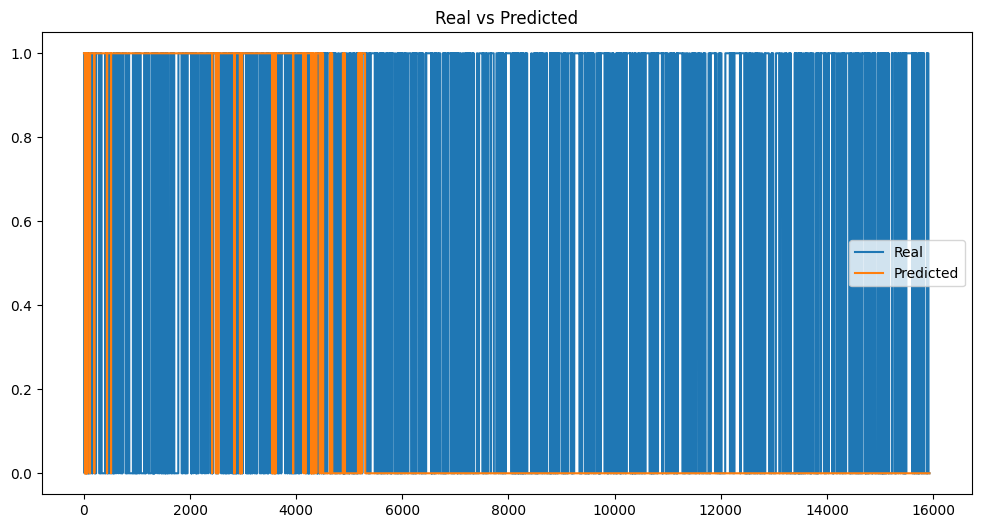

In [15]:
preds = model.predict(X_test)
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Real")
plt.plot(preds, label="Predicted")
plt.legend()
plt.title("Real vs Predicted")
plt.show()


In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

base = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced")
)

sfs = SequentialFeatureSelector(
    base,
    n_features_to_select=8,      # cambia este número y ya
    direction="forward",
    cv=TimeSeriesSplit(n_splits=5),
    scoring="MCC",
    n_jobs=-1
)

sfs.fit(X_train, y_train)
sel = X_train.columns[sfs.get_support()].tolist()
print("selected:", sel)

base.fit(X_train[sel], y_train)
pred = base.predict(X_test[sel])

print("acc:", accuracy_score(y_test, pred))
print(confusion_matrix(y_test, pred))


InvalidParameterError: The 'scoring' parameter of SequentialFeatureSelector must be None, a str among {'neg_root_mean_squared_error', 'mutual_info_score', 'neg_mean_absolute_error', 'precision_macro', 'f1', 'recall_samples', 'jaccard_macro', 'neg_brier_score', 'adjusted_rand_score', 'neg_mean_squared_error', 'neg_negative_likelihood_ratio', 'recall', 'explained_variance', 'average_precision', 'jaccard', 'fowlkes_mallows_score', 'matthews_corrcoef', 'precision_samples', 'f1_weighted', 'precision_micro', 'homogeneity_score', 'recall_micro', 'roc_auc', 'neg_mean_squared_log_error', 'f1_micro', 'recall_weighted', 'r2', 'neg_mean_poisson_deviance', 'roc_auc_ovr_weighted', 'recall_macro', 'f1_macro', 'f1_samples', 'roc_auc_ovo', 'roc_auc_ovo_weighted', 'neg_median_absolute_error', 'adjusted_mutual_info_score', 'balanced_accuracy', 'jaccard_samples', 'roc_auc_ovr', 'neg_mean_absolute_percentage_error', 'top_k_accuracy', 'completeness_score', 'jaccard_micro', 'neg_root_mean_squared_log_error',